In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import os

In [4]:
!ls

BH3-2.regions.bed WW2-5.regions.bed WW5-3.regions.bed iton_cov.ipynb
WW1-2.regions.bed WW2-6.regions.bed WW5-4.regions.bed
WW1-4.regions.bed WW3-1.regions.bed WW5-5.regions.bed
WW2-1.regions.bed WW5-1.regions.bed WW5-6.regions.bed


In [5]:
files = os.listdir()
files = [file for file in files if 'biallelic' in file]

In [6]:
df_list = []
for file in files:
    chromosome = file.split('.')[0]
    degen = file.split('.')[2].split('_')[0]
    df = pd.read_csv(file, sep = '\t')
    df['chromosome'] = chromosome
    df['degen'] = degen
    df_list.append(df)
iton_df = pd.concat(df_list)

In [7]:
iton_df

,ref_allele_count,alt_allele_count,pos,chromosome,degen
0,22.0,2.0,242905.0,OX359249,4D
1,20.0,4.0,275416.0,OX359249,4D
2,19.0,5.0,275623.0,OX359249,4D
3,19.0,5.0,275659.0,OX359249,4D
4,19.0,5.0,275719.0,OX359249,4D
...,...,...,...,...,...
24794,11.0,13.0,75416324.0,OX359246,0D
24795,11.0,13.0,75416510.0,OX359246,0D
24796,23.0,1.0,75416575.0,OX359246,0D
24797,11.0,13.0,75416756.0,OX359246,0D


In [8]:
x_chroms = ['OX359249.1.0D_pi.biallelic_ac.txt',
           'OX359249.1.4D_pi.biallelic_ac.txt',
           'OX359250.1.0D_pi.biallelic_ac.txt',
           'OX359250.1.4D_pi.biallelic_ac.txt']

In [9]:
iton_df['MAC'] = iton_df[['ref_allele_count','alt_allele_count']].min(axis=1)

In [10]:
iton_df

,ref_allele_count,alt_allele_count,pos,chromosome,degen,MAC
0,22.0,2.0,242905.0,OX359249,4D,2.0
1,20.0,4.0,275416.0,OX359249,4D,4.0
2,19.0,5.0,275623.0,OX359249,4D,5.0
3,19.0,5.0,275659.0,OX359249,4D,5.0
4,19.0,5.0,275719.0,OX359249,4D,5.0
...,...,...,...,...,...,...
24794,11.0,13.0,75416324.0,OX359246,0D,11.0
24795,11.0,13.0,75416510.0,OX359246,0D,11.0
24796,23.0,1.0,75416575.0,OX359246,0D,1.0
24797,11.0,13.0,75416756.0,OX359246,0D,11.0


(0.0, 13.0)

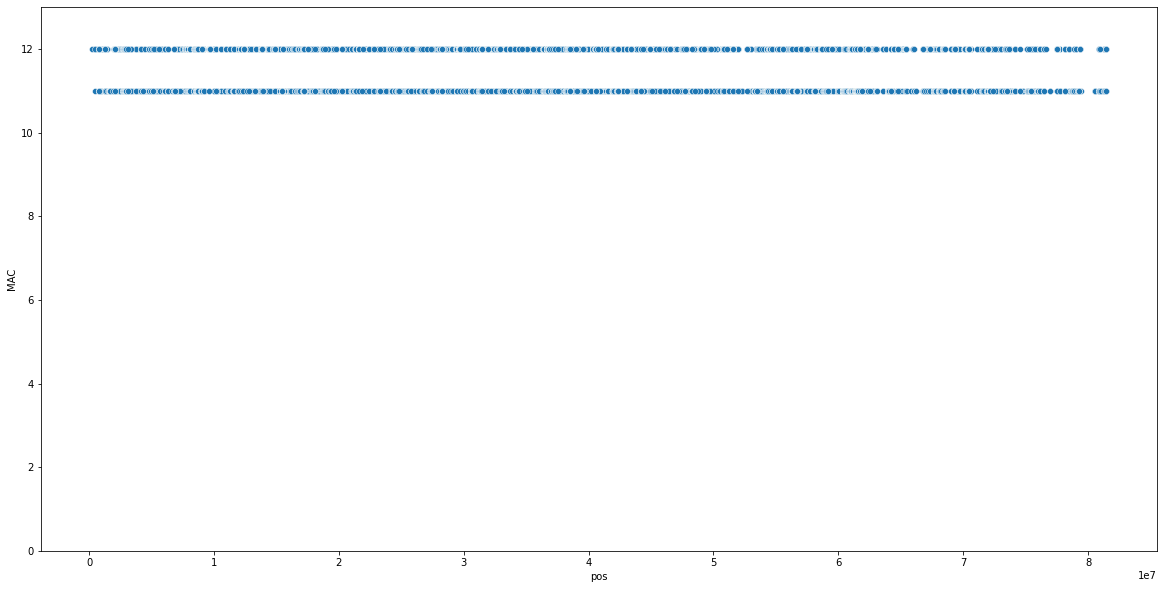

In [11]:
fig, axs = plt.subplots(figsize=[20,10])

sns.scatterplot(data = iton_df[iton_df['MAC']>=11],
            x = 'pos',
            y='MAC',
            ax = axs)

axs.set_ylim(0, 13)

In [12]:
results = []
increment = 1_000_000
for i in range(0, int(df['pos'].max()+increment), increment):
    mean = df[(df['pos']>i) & (df['pos']<i+increment)]['MAC'].mean()
    results.append(np.array((i+(increment/2), mean)))
results = np.array(results)
df2 = pd.DataFrame(results, columns=['midpoint','mean_MAC'])

KeyError: 'MAC'

NameError: name 'df2' is not defined

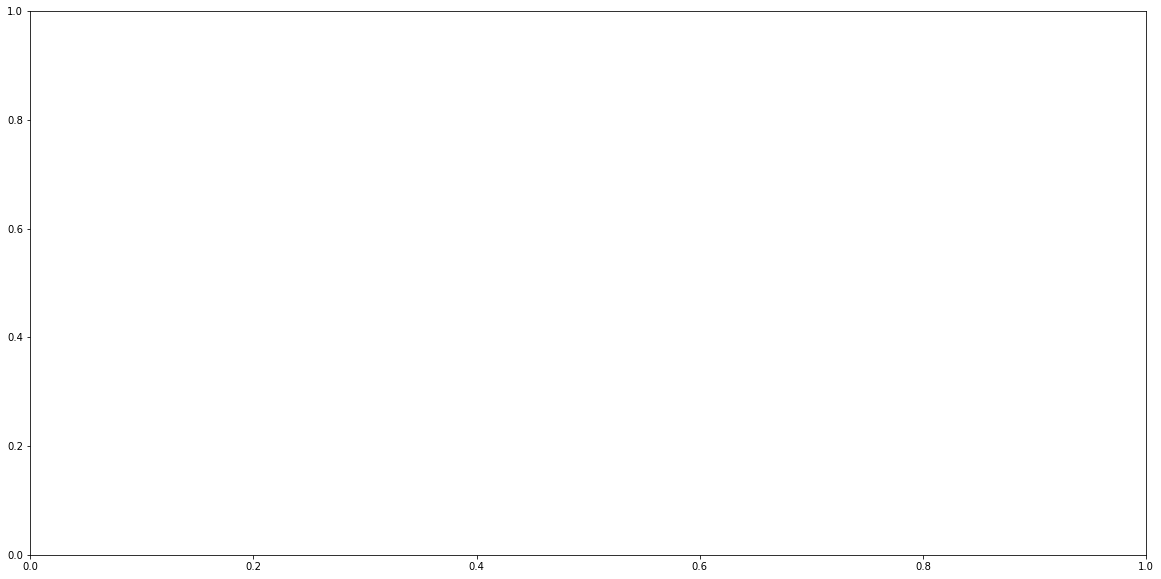

In [13]:
fig, axs = plt.subplots(figsize=[20,10])

sns.scatterplot(data = df2,
            x = 'midpoint',
            y='mean_MAC',
            ax = axs)

axs.set_ylim(0, 13)

In [14]:
df = pd.read_csv(x_chroms[2], sep='\t')
#df = pd.read_csv('OX359246.1.0D_pi.biallelic_ac.txt', sep='\t')

df['MAC'] = df[['ref_allele_count','alt_allele_count']].min(axis=1)

In [15]:
df[(df['MAC']==11)&(df['pos']<5_000_000)].shape[0]
# 35
# 90
# 15
# 56

4

In [16]:
df

,ref_allele_count,alt_allele_count,pos,MAC
0,18.0,6.0,1702876.0,6.0
1,23.0,1.0,1703165.0,1.0
2,17.0,7.0,1703363.0,7.0
3,23.0,1.0,1703399.0,1.0
4,23.0,1.0,1703414.0,1.0
...,...,...,...,...
2501,16.0,8.0,47561635.0,8.0
2502,19.0,5.0,47561692.0,5.0
2503,19.0,5.0,47822120.0,5.0
2504,20.0,4.0,47822157.0,4.0


In [17]:
results = []
increment = 2_000
for i in range(0, int(df['pos'].max()+increment), increment):
    count = df[(df['pos']>i) & (df['pos']<i+increment) & (df['MAC']==12)]['MAC'].shape[0]
    results.append(np.array((i+(increment/2), count)))
results = np.array(results)
df2 = pd.DataFrame(results, columns=['midpoint','MAC = 12 count'])
df2['MAC_prop'] = df2['MAC = 12 count']/df2['MAC = 12 count'].sum()

In [19]:
df2.shape[0]

23913

In [21]:
np.sum(df2['MAC = 12 count'] > 5)

17

<AxesSubplot:xlabel='midpoint', ylabel='MAC = 12 count'>

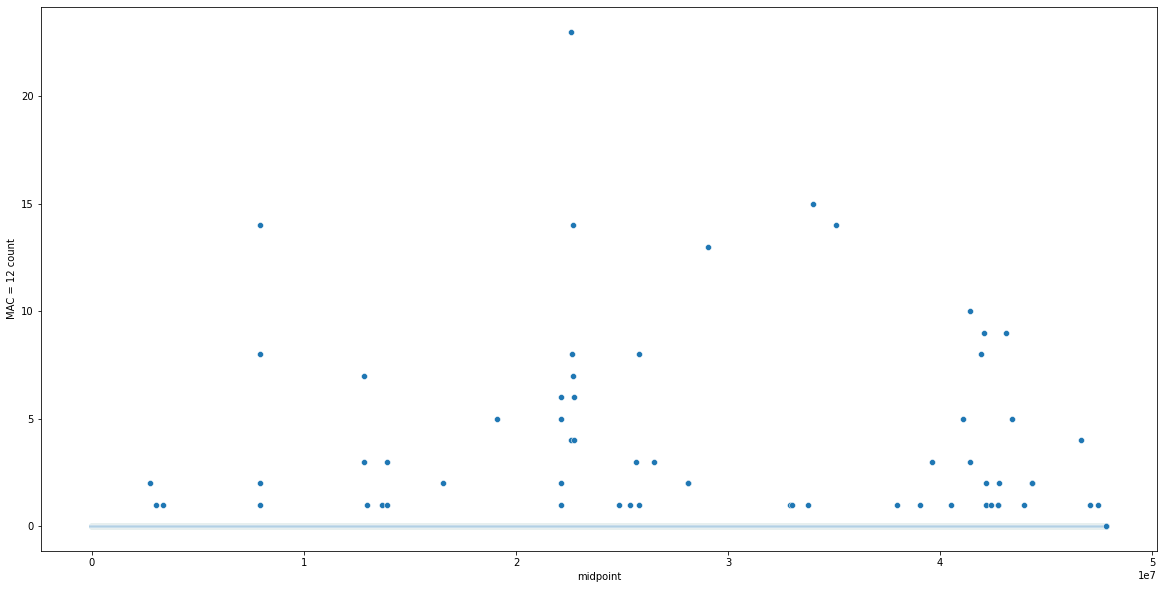

In [18]:
fig, axs = plt.subplots(figsize=[20,10])

sns.scatterplot(data = df2,
            x = 'midpoint',
            y = 'MAC = 12 count',
            ax = axs)

#axs.set_ylim(0, 13)

In [ ]:
df2[(df2['MAC = 12 count']>40)]

In [ ]:
fig, axs = plt.subplots(figsize=[20,10])

sns.scatterplot(data = df2,
            x = 'midpoint',
            y = 'MAC_prop',
            ax = axs)

#axs.set_ylim(0, 13)

In [ ]:
df2.sort_values(by=['MAC_prop'])

In [ ]:
files = os.listdir()
files = [file for file in files if 'bed' in file]

In [ ]:
df_list = []
for file in files:
    sample = file.split('.')[0]
    df = pd.read_csv(file, sep = '\t', names=['chromosome', 'start','stop','cov'], header=None)
    df['sample'] = sample
    df_list.append(df)
cov_df = pd.concat(df_list)
cov_df['midpoint'] = cov_df['start'] + ((cov_df['stop']-cov_df['start'])/2)
cov_df['chromosome'] = cov_df['chromosome'].str.split('.', expand=True)[0]
cov_df = cov_df[~cov_df['chromosome'].str.contains('CA')]

In [ ]:
cov_df

In [ ]:
tmp_df = iton_df[iton_df['chromosome']=='OX359250']

In [ ]:
for index, rac, aac, pos, chr, deg, mac, cov in iton_df.itertuples():
    mean_cov = cov_df[(cov_df['chromosome']==chr) & (cov_df['start'] <= pos) & (cov_df['stop'] >= pos)]['cov'].mean()
    iton_df.at[index,'cov'] = mean_cov

In [ ]:
plt.plot(tmp_df.groupby('MAC')['cov'].mean())

In [ ]:
iton_df[iton_df['chromosome'] == 'OX359249'].groupby('MAC')['cov'].describe()

In [ ]:
iton_df[iton_df['chromosome'] == 'OX359250'].groupby('MAC')['cov'].describe()

In [ ]:
iton_df['cov'].mean()

In [ ]:
iton_df

In [ ]:
chrom = 'OX359250'
df = iton_df[iton_df['chromosome']==chrom]

results = []
increment = 500_000
for i in range(0, int(df['pos'].max()+increment), increment):
    count = df[(df['pos']>i) & (df['pos']<i+increment) & (df['MAC']==12)]['MAC'].shape[0]
    cov_mean = df[(df['pos']>i) & (df['pos']<i+increment) & (df['MAC']==12)]['cov'].max()
    results.append(np.array((i+(increment/2), count, cov_mean)))
results = np.array(results)
mean_df = pd.DataFrame(results, columns=['midpoint','12ton_count', 'mean_cov'])
mean_df['12ton_prop'] = mean_df['12ton_count']/mean_df['12ton_count'].sum()

In [ ]:
fig, axs = plt.subplots(nrows=2,figsize=[20,10])

sns.scatterplot(data = mean_df,
            x = 'midpoint',
            y = '12ton_prop',
            ax = axs[0])

sns.scatterplot(data = mean_df,
            x = 'midpoint',
            y = 'mean_cov',
            ax = axs[1])

#axs.set_ylim(0, 13)

In [ ]:
mean_df.dropna()

In [ ]:
fig, axs = plt.subplots(figsize=[20,10])

sns.scatterplot(data = mean_df,
            x = '12ton_prop',
            y = 'mean_cov',
            ax = axs)

In [ ]:
chrom = 'OX359250'

cov1 = iton_df[(iton_df['chromosome']==chrom) & (iton_df['MAC']==12)]['cov']
cov2 = iton_df[(iton_df['chromosome']==chrom) & (iton_df['MAC']<12)]['cov']

In [ ]:
fig, axs = plt.subplots(figsize=[8,8])

bins = np.arange(0, 70, 5)

sns.histplot(cov1, bins = bins, alpha = 0.5, stat='proportion', label='12tons')
sns.histplot(cov2, bins = bins, alpha = 0.5, stat='proportion', label='<12tons', color='orange')

axs.legend()

axs.set_title(chrom, loc = 'right')

In [ ]:
cov1.index

In [ ]:
test_list = iton_df[(iton_df['chromosome']==chrom) & (iton_df['MAC']==12) & (iton_df['cov']<25)]['pos'].to_list()

In [ ]:
test_list

In [ ]:
len([i for i in test_list if i < 20000000])

In [ ]:
22_617_795
17_033_757

In [ ]:
23338604.0-22617795.0

In [ ]:
17033757.0-17032418.0

In [ ]:
!ls

In [ ]:
files = os.listdir()
files = [file for file in files if 'dp' in file]

In [ ]:
files

In [ ]:
df_list = []
for file in files:
    chromosome = file.split('.')[0]
    degen = file.split('.')[2].split('_')[0]
    df = pd.read_csv(file, sep = '\t', header=None)
    df['chromosome'] = chromosome
    df['degen'] = degen
    df_list.append(df)
allcov_df = pd.concat(df_list)
sample_heads = ['sample_' + str(i+1) for i in range(allcov_df.shape[1]-3)]
allcov_df.columns = ['pos'] + sample_heads + ['chromosome','degen']

In [ ]:
allcov_df.columns

In [ ]:
['pos'] + sample_heads + ['chromosome','degen']

In [ ]:
allcov_df

In [ ]:
chromosome = 'OX359250'
sample = 'sample_4'
df = iton_df.loc[iton_df['chromosome'] == chromosome][['pos', 'MAC']].merge(allcov_df.loc[(allcov_df['chromosome']==chromosome)][['pos', sample]], on='pos')

In [ ]:
df[df['sample_4'] > 66]

In [ ]:
cov1 = df[df['MAC']==12][sample]
cov2 = df[df['MAC']<12][sample]
cov3 = df[sample]

fig, axs = plt.subplots(figsize=[8,8])

bins = np.arange(0, 150, 5)

sns.histplot(cov1, bins = bins, alpha = 0.5, stat='proportion', label='12tons')
sns.histplot(cov2, bins = bins, alpha = 0.5, stat='proportion', label='<12tons', color='orange')
sns.histplot(cov3, bins = bins, alpha = 0.5, stat='proportion', label='all', color='grey')

axs.legend()

axs.set_title(chromosome, loc = 'right')

In [ ]:
np.mean(df[sample]) + (2*np.std(df[sample]))

In [ ]:
df[(df['pos']<17040000) & (df['MAC']==12)]['sample_1'].describe()

In [ ]:
df[(df['pos']>22600000) & (df['pos']<22800000) & (df['MAC']==12)]['sample_1'].describe()

In [ ]:
allcov_df['sample_1'].describe()

In [ ]:
4.178053e+01 + (2*1.765113e+01)